<a href="https://colab.research.google.com/github/maiaragoudapatil-art/AI-Powered-Stock-Prediction-System-for-Tesla-TSLA-/blob/main/AI_Powered_Stock_Prediction_System_for_Tesla_(TSLA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced AI-Powered Stock Prediction System for Tesla (TSLA)

## 1. Data Handling & Preprocessing

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

print("Libraries imported successfully.")

Libraries imported successfully.


### Load Stock Dataset

In [2]:
# Load the dataset
df = pd.read_csv('/content/TSLA.csv')

# Display the first few rows and information about the dataset
print("Original DataFrame head:")
display(df.head())
print("\nDataFrame Info:")
df.info()

Original DataFrame head:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


### Convert Date Column and Handle Missing Values

In [3]:
# Convert 'Date' column to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Handle missing values using forward fill
df.fillna(method='ffill', inplace=True)

print("DataFrame after date conversion and missing value handling:")
display(df.head())
print(f"Number of missing values after forward fill: {df.isnull().sum().sum()}")

DataFrame after date conversion and missing value handling:


/tmp/ipykernel_6321/3182201730.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


Number of missing values after forward fill: 0


### Feature Engineering

In [4]:
# Moving Average (MA 10, MA 50)
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

# Exponential Moving Average (EMA)
df['EMA'] = df['Close'].ewm(span=20, adjust=False).mean()

# Daily Returns
df['Daily_Return'] = df['Close'].pct_change()

# Volatility (using a 20-day rolling standard deviation of daily returns)
df['Volatility'] = df['Daily_Return'].rolling(window=20).std()

# Drop rows with NaN values created by rolling windows
df.dropna(inplace=True)

print("DataFrame after feature engineering:")
display(df.head())
print(f"Number of missing values after feature engineering: {df.isnull().sum().sum()}")

DataFrame after feature engineering:


,Open,High,Low,Close,Adj Close,Volume,MA10,MA50,EMA,Daily_Return,Volatility
Date,,,,,,,,,,,
2010-09-08,20.660000,20.950001,20.600000,20.900000,20.900000,288400,20.270,19.8336,20.056256,0.017527,0.030604
2010-09-09,21.000000,21.049999,20.690001,20.709999,20.709999,376200,20.351,19.7700,20.118517,-0.009091,0.026861
2010-09-10,20.750000,20.930000,19.760000,20.170000,20.170000,386600,20.393,19.6968,20.123420,-0.026074,0.027382
2010-09-13,20.889999,20.900000,20.500000,20.719999,20.719999,360800,20.495,19.6720,20.180237,0.027268,0.026658
2010-09-14,20.540001,21.600000,20.530001,21.120001,21.120001,654700,20.620,19.7104,20.269739,0.019305,0.026476


Number of missing values after feature engineering: 0


### Normalize Data

In [5]:
# Select features for scaling
features = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'MA10', 'MA50', 'EMA', 'Daily_Return', 'Volatility']
data = df[features].values

# Normalize data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print("Shape of scaled data:", scaled_data.shape)
print("First 5 rows of scaled data:\n", scaled_data[:5])

Shape of scaled data: (2367, 11)
First 5 rows of scaled data:
 [[1.17773172e-03 1.05744384e-03 1.68190570e-03 1.76213902e-03
  1.76213902e-03 3.61901313e-03 0.00000000e+00 3.81196625e-04
  0.00000000e+00 4.82134151e-01 2.81019146e-01]
 [1.69776842e-03 1.18798953e-03 1.81951770e-03 1.51228236e-03
  1.51228236e-03 5.48922710e-03 1.38975218e-04 2.31171221e-04
  1.14777587e-04 4.21255441e-01 2.30302513e-01]
 [1.31538849e-03 1.03133288e-03 3.97541347e-04 8.02168480e-04
  8.02168480e-04 5.71075586e-03 2.11036531e-04 5.85004722e-05
  1.23816420e-04 3.82411911e-01 2.37365885e-01]
 [1.52951972e-03 9.92168387e-04 1.52900518e-03 1.52543264e-03
  1.52543264e-03 5.16119413e-03 3.86042234e-04 0.00000000e+00
  2.28557666e-04 5.04414319e-01 2.27560538e-01]
 [9.94190880e-04 1.90600649e-03 1.57487687e-03 2.05144653e-03
  2.05144653e-03 1.14215117e-02 6.00510428e-04 9.05813763e-05
  3.93551853e-04 4.86201598e-01 2.25092536e-01]]


## 2. Time Series Preparation

### Create Sequences

In [6]:
X = []
y = []

# Define the number of past days to use for prediction
look_back = 60

# Create sequences
for i in range(look_back, len(scaled_data)):
    X.append(scaled_data[i-look_back:i, :])
    y.append(scaled_data[i, 3]) # Predicting 'Close' price (index 3 in features list)

X, y = np.array(X), np.array(y)

print("Shape of X (sequences):", X.shape)
print("Shape of y (target):", y.shape)

Shape of X (sequences): (2307, 60, 11)
Shape of y (target): (2307,)


### Split into Training and Testing Sets

In [7]:
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size

X_train, X_test = X[0:train_size,:], X[train_size:len(X),:]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

print(f"Training set size: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Testing set size: X_test {X_test.shape}, y_test {y_test.shape}")

Training set size: X_train (1845, 60, 11), y_train (1845,)
Testing set size: X_test (462, 60, 11), y_test (462,)


## 3. Model Building

### SimpleRNN Model

In [8]:
# SimpleRNN Model
rnn_model = Sequential([
    SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    SimpleRNN(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

rnn_model.compile(optimizer='adam', loss='mean_squared_error')
print("SimpleRNN Model Summary:")
rnn_model.summary()

SimpleRNN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         3,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,201 (32.04 KB)

 Trainable params: 8,201 (32.04 KB)

 Non-trainable params: 0 (0.00 B)

### LSTM Model

In [9]:
# LSTM Model
lstm_model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
print("LSTM Model Summary:")
lstm_model.summary()

LSTM Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        12,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,651 (127.54 KB)

 Trainable params: 32,651 (127.54 KB)

 Non-trainable params: 0 (0.00 B)

### GRU Model

In [10]:
# GRU Model
gru_model = Sequential([
    GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    GRU(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

gru_model.compile(optimizer='adam', loss='mean_squared_error')
print("GRU Model Summary:")
gru_model.summary()

GRU Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 50)         │         9,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,801 (96.88 KB)

 Trainable params: 24,801 (96.88 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Model Training

In [11]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training SimpleRNN Model...")
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("Training LSTM Model...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("Training GRU Model...")
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("All models trained successfully.")

Training SimpleRNN Model...
Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.1601 - val_loss: 0.0071
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0693 - val_loss: 0.0065
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0424 - val_loss: 0.0041
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0286 - val_loss: 0.0025
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0210 - val_loss: 8.3988e-04
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0164 - val_loss: 8.6356e-04
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0130 - val_loss: 4.2643e-04
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0121 - val_loss: 3.3103e-04
Epoch 9/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0093 - val_loss: 5.8465e-04
Epoch 10/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0075 - val_loss: 6.2730e-04
Epoch 11/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0067 - val_loss: 8.4258e-04
Epoch 1

## 5. Prediction

In [12]:
print("Making predictions...")

rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

print("Predictions made successfully.")

Making predictions...
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
Predictions made successfully.


### Inverse Scaling

In [13]:
# To inverse scale, we need to create dummy arrays with the same number of features as the original scaled_data
# Then replace the 'Close' price column with the predictions and inverse transform

def inverse_scale_predictions(predictions, original_data_shape, close_price_idx=3):
    # Create a dummy array for inverse transformation
    dummy_array = np.zeros((len(predictions), original_data_shape[1]))
    # Place the predictions into the 'Close' price column
    dummy_array[:, close_price_idx] = predictions.flatten()
    # Inverse transform the dummy array
    inverted_predictions = scaler.inverse_transform(dummy_array)[:, close_price_idx]
    return inverted_predictions

original_data_shape = scaled_data.shape
close_price_index = features.index('Close') # Get the index of the 'Close' price in the features list

# Inverse scale RNN predictions
rnn_pred_actual = inverse_scale_predictions(rnn_pred, original_data_shape, close_price_index)

# Inverse scale LSTM predictions
lstm_pred_actual = inverse_scale_predictions(lstm_pred, original_data_shape, close_price_index)

# Inverse scale GRU predictions
gru_pred_actual = inverse_scale_predictions(gru_pred, original_data_shape, close_price_index)

# Inverse scale actual test values (y_test)
dummy_y_test = np.zeros((len(y_test), original_data_shape[1]))
dummy_y_test[:, close_price_index] = y_test.flatten()
y_test_actual = scaler.inverse_transform(dummy_y_test)[:, close_price_index]

print("Inverse scaling complete. Sample of actual vs. predicted (RNN):")
print(f"Actual: {y_test_actual[:5]}")
print(f"RNN Predicted: {rnn_pred_actual[:5]}")

Inverse scaling complete. Sample of actual vs. predicted (RNN):
Actual: [286.940002 305.720001 299.299988 289.660004 304.700012]
RNN Predicted: [266.67028773 266.82885988 283.35934445 286.52976778 283.33996769]


## 6. Evaluation

In [14]:
metrics = {}

def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    metrics[model_name] = {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"\n{model_name} Evaluation:")
    print(f"  MSE: {mse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R2 Score: {r2:.4f}")
    return rmse # Return RMSE for comparison

print("Evaluating SimpleRNN Model...")
rnn_rmse = evaluate_model(y_test_actual, rnn_pred_actual, 'SimpleRNN')

print("Evaluating LSTM Model...")
lstm_rmse = evaluate_model(y_test_actual, lstm_pred_actual, 'LSTM')

print("Evaluating GRU Model...")
gru_rmse = evaluate_model(y_test_actual, gru_pred_actual, 'GRU')

# Identify the best model based on RMSE
min_rmse = min(rnn_rmse, lstm_rmse, gru_rmse)

best_model_name = ''
if min_rmse == rnn_rmse:
    best_model_name = 'SimpleRNN'
elif min_rmse == lstm_rmse:
    best_model_name = 'LSTM'
else:
    best_model_name = 'GRU'

print(f"\nBest Model based on RMSE: {best_model_name}")
print("All evaluation metrics:")
for model, model_metrics in metrics.items():
    print(f"  {model}: {model_metrics}")

Evaluating SimpleRNN Model...

SimpleRNN Evaluation:
  MSE: 570.6220
  MAE: 14.1904
  RMSE: 23.8877
  R2 Score: 0.8937
Evaluating LSTM Model...

LSTM Evaluation:
  MSE: 2686.3319
  MAE: 33.4508
  RMSE: 51.8298
  R2 Score: 0.4994
Evaluating GRU Model...

GRU Evaluation:
  MSE: 554.0547
  MAE: 16.2116
  RMSE: 23.5384
  R2 Score: 0.8968

Best Model based on RMSE: GRU
All evaluation metrics:
  SimpleRNN: {'MSE': 570.6219692232236, 'MAE': 14.190352067566915, 'RMSE': np.float64(23.887694933233377), 'R2': 0.893664447680386}
  LSTM: {'MSE': 2686.3319241846148, 'MAE': 33.45079908984155, 'RMSE': np.float64(51.82983623536365), 'R2': 0.49940134751412435}
  GRU: {'MSE': 554.054662792283, 'MAE': 16.211642973363812, 'RMSE': np.float64(23.538365762989642), 'R2': 0.8967517695410927}


## 7. Visualization

### Plot Actual vs Predicted Values

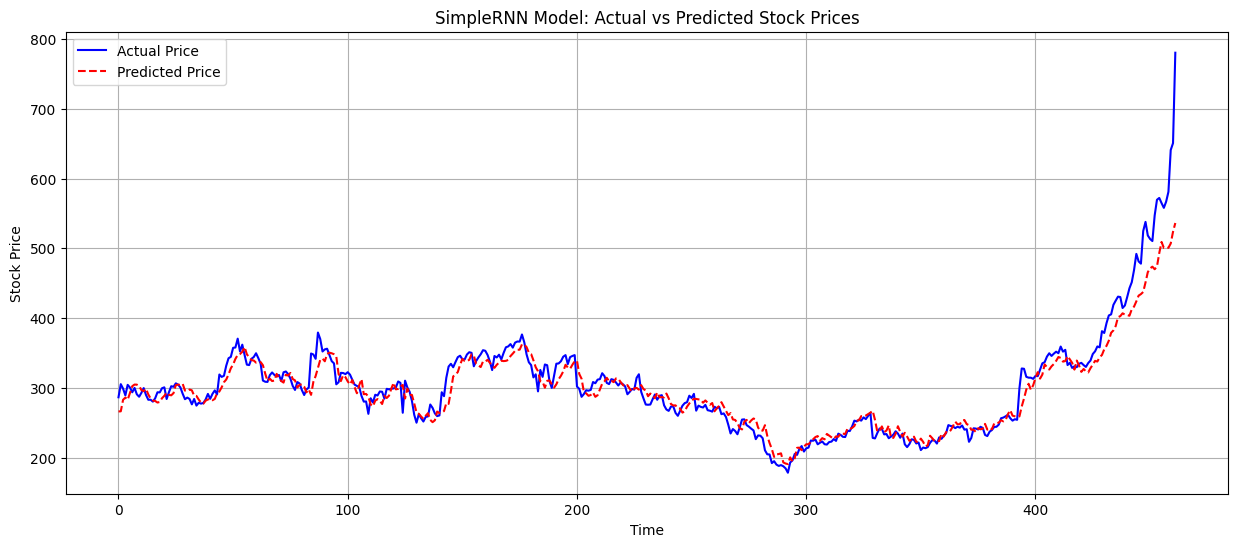

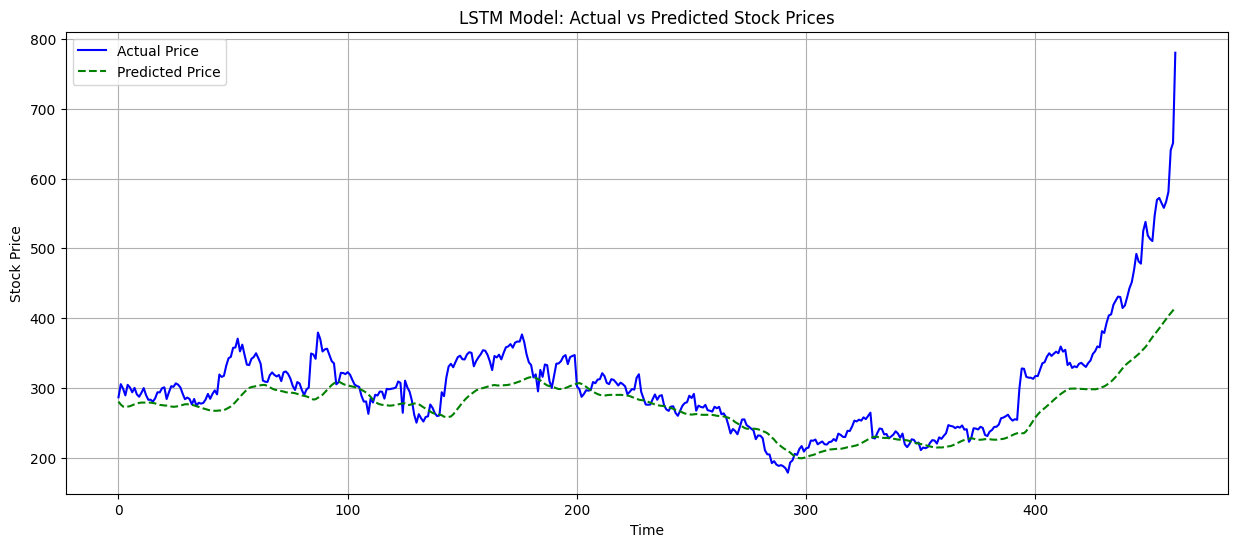

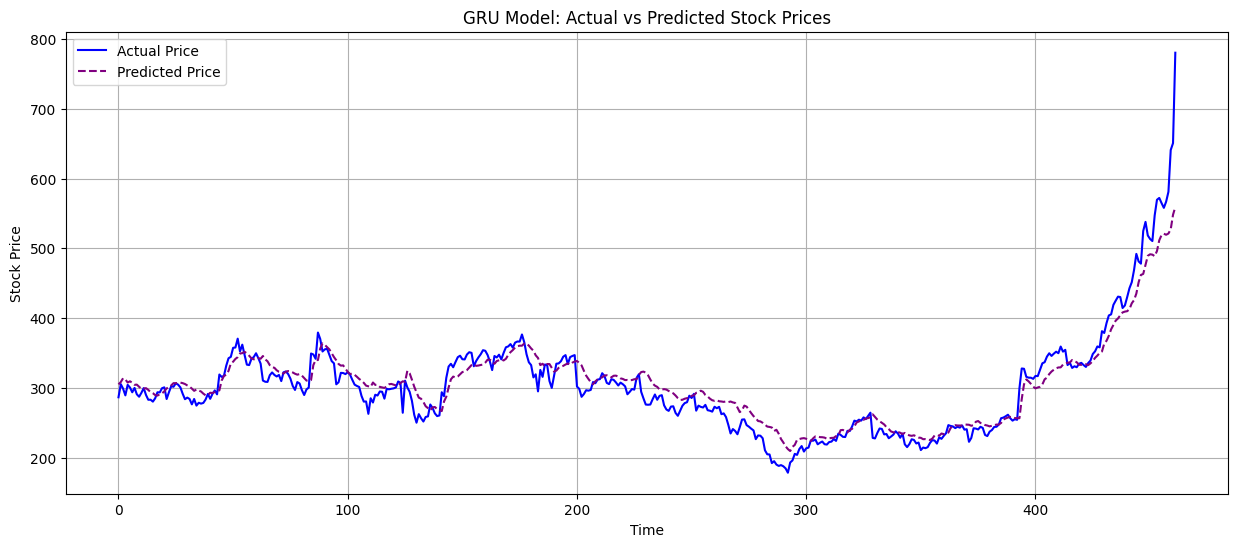

In [15]:
plt.figure(figsize=(15, 6))
plt.title('SimpleRNN Model: Actual vs Predicted Stock Prices')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.plot(y_test_actual, label='Actual Price', color='blue')
plt.plot(rnn_pred_actual, label='Predicted Price', color='red', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
plt.title('LSTM Model: Actual vs Predicted Stock Prices')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.plot(y_test_actual, label='Actual Price', color='blue')
plt.plot(lstm_pred_actual, label='Predicted Price', color='green', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
plt.title('GRU Model: Actual vs Predicted Stock Prices')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.plot(y_test_actual, label='Actual Price', color='blue')
plt.plot(gru_pred_actual, label='Predicted Price', color='purple', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

### Plot Comparison of All Models

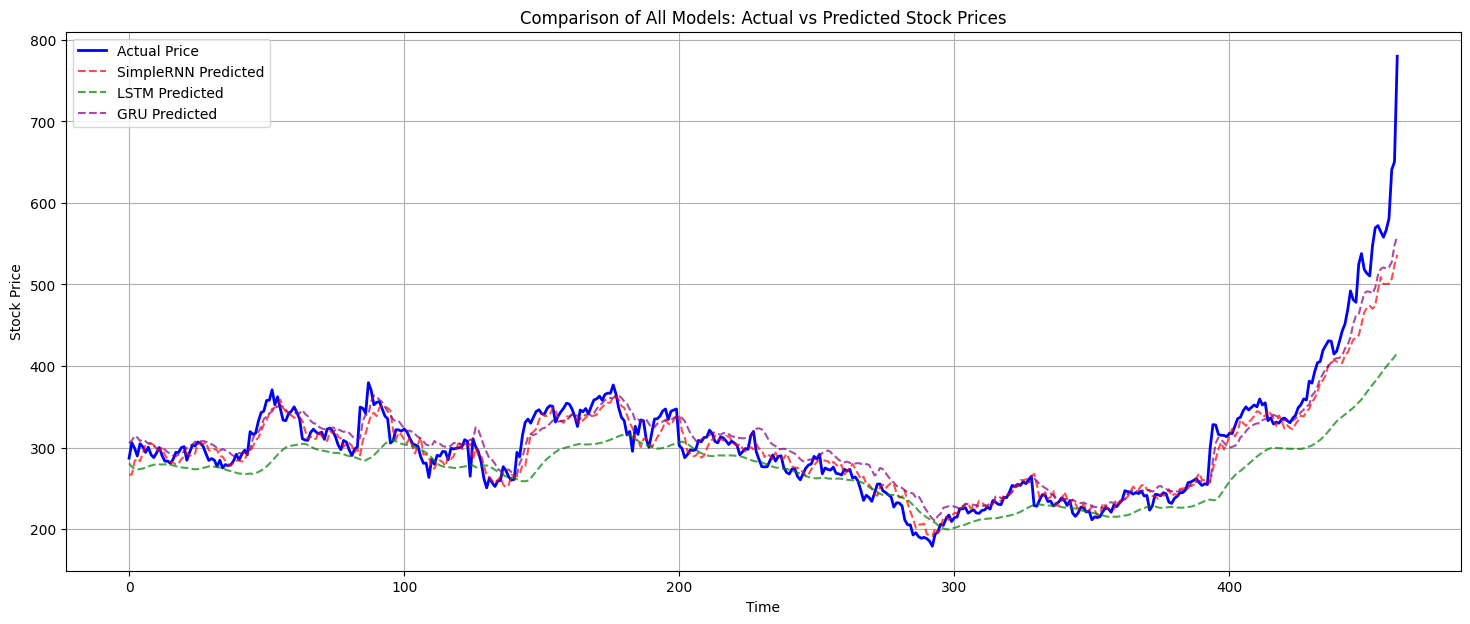

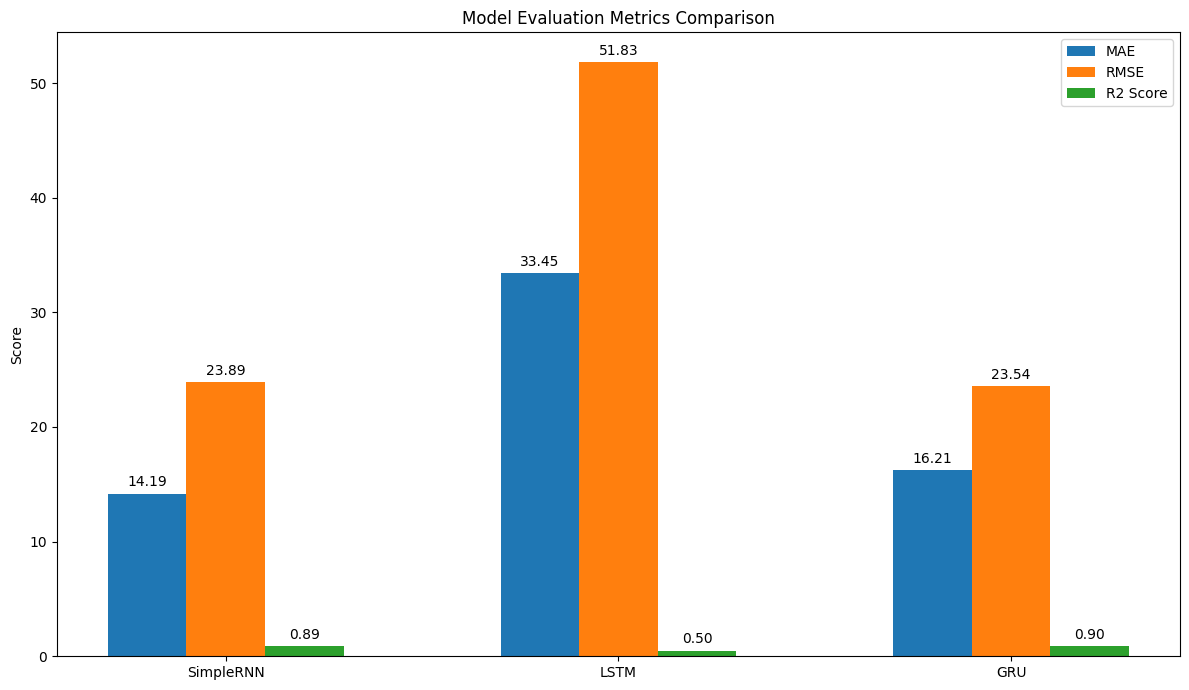

In [16]:
plt.figure(figsize=(18, 7))
plt.title('Comparison of All Models: Actual vs Predicted Stock Prices')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.plot(y_test_actual, label='Actual Price', color='blue', linewidth=2)
plt.plot(rnn_pred_actual, label='SimpleRNN Predicted', color='red', linestyle='--', alpha=0.7)
plt.plot(lstm_pred_actual, label='LSTM Predicted', color='green', linestyle='--', alpha=0.7)
plt.plot(gru_pred_actual, label='GRU Predicted', color='purple', linestyle='--', alpha=0.7)
plt.legend()
plt.grid(True)
plt.show()

# Plotting metrics for comparison
model_names = list(metrics.keys())
mse_values = [metrics[name]['MSE'] for name in model_names]
mae_values = [metrics[name]['MAE'] for name in model_names]
rmse_values = [metrics[name]['RMSE'] for name in model_names]
r2_values = [metrics[name]['R2'] for name in model_names]

x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width, mae_values, width, label='MAE')
rects2 = ax.bar(x, rmse_values, width, label='RMSE')
rects3 = ax.bar(x + width, r2_values, width, label='R2 Score')

ax.set_ylabel('Score')
ax.set_title('Model Evaluation Metrics Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

## 8. Multi-Step Forecasting

### Implement prediction for 1, 5, and 10 days ahead

In [17]:
def predict_future_steps(model, initial_sequence, num_steps, original_data_shape, close_price_idx, scaler):
    current_sequence = initial_sequence.copy()
    future_predictions = []

    for _ in range(num_steps):
        # Predict the next step
        predicted_scaled_price = model.predict(current_sequence.reshape(1, look_back, current_sequence.shape[1]), verbose=0)[0, 0]

        # Inverse scale the predicted price to get the actual value
        dummy_pred = np.zeros((1, original_data_shape[1]))
        dummy_pred[:, close_price_idx] = predicted_scaled_price
        actual_predicted_price = scaler.inverse_transform(dummy_pred)[:, close_price_idx][0]
        future_predictions.append(actual_predicted_price)

        # Update the sequence for the next prediction
        # The simplest way is to append the predicted 'Close' price (scaled) and remove the oldest data point.
        # However, for a more robust multi-step prediction, one would typically predict all features
        # or use a more sophisticated method to estimate future features. Here, we only update the 'Close' price.
        new_feature_values = current_sequence[-1, :].copy()
        new_feature_values[close_price_idx] = predicted_scaled_price

        # Remove the first (oldest) entry and append the new predicted feature vector
        current_sequence = np.vstack((current_sequence[1:], new_feature_values))

    return future_predictions

# Get the last `look_back` days from the scaled data to start multi-step prediction
last_sequence = scaled_data[-look_back:]

# Predict 1 day ahead
pred_1_day = predict_future_steps(gru_model, last_sequence, 1, original_data_shape, close_price_index, scaler)
print(f"Predicted price for 1 day ahead (GRU): {pred_1_day[0]:.2f}")

# Predict 5 days ahead
pred_5_days = predict_future_steps(gru_model, last_sequence, 5, original_data_shape, close_price_index, scaler)
print(f"Predicted prices for 5 days ahead (GRU): {', '.join([f'{p:.2f}' for p in pred_5_days])}")

# Predict 10 days ahead
pred_10_days = predict_future_steps(gru_model, last_sequence, 10, original_data_shape, close_price_index, scaler)
print(f"Predicted prices for 10 days ahead (GRU): {', '.join([f'{p:.2f}' for p in pred_10_days])}")

Predicted price for 1 day ahead (GRU): 593.62
Predicted prices for 5 days ahead (GRU): 593.62, 621.32, 638.45, 648.29, 654.02
Predicted prices for 10 days ahead (GRU): 593.62, 621.32, 638.45, 648.29, 654.02, 657.60, 660.03, 661.80, 663.13, 664.14


## 9. Trading Strategy (Business Feature)

### Generate Buy/Sell Signals and Simulate Profit

In [18]:
def generate_trading_signals(actual_prices, predicted_prices):
    signals = []
    for i in range(len(predicted_prices)):
        if predicted_prices[i] > actual_prices[i]:
            signals.append('BUY')
        else:
            signals.append('SELL')
    return signals

def simulate_profit(actual_prices, predicted_prices, initial_capital=10000, transaction_cost_rate=0.001):
    capital = initial_capital
    shares = 0
    trade_log = []

    for i in range(len(predicted_prices)):
        current_price = actual_prices[i]
        predicted_price = predicted_prices[i]

        if predicted_price > current_price and capital > 0: # BUY signal
            if shares == 0: # Only buy if we don't hold shares
                buy_amount = capital * 0.95 # Use 95% of capital to buy
                num_shares_to_buy = buy_amount / current_price
                cost = num_shares_to_buy * current_price * (1 + transaction_cost_rate)
                if cost <= capital:
                    shares += num_shares_to_buy
                    capital -= cost
                    trade_log.append(f"Day {i+1}: BUY {num_shares_to_buy:.2f} shares at {current_price:.2f}. Capital: {capital:.2f}")

        elif predicted_price <= current_price and shares > 0: # SELL signal
            sell_amount = shares * current_price * (1 - transaction_cost_rate)
            capital += sell_amount
            trade_log.append(f"Day {i+1}: SELL {shares:.2f} shares at {current_price:.2f}. Capital: {capital:.2f}")
            shares = 0 # All shares sold

    # Liquidate any remaining shares at the last actual price
    if shares > 0:
        final_value = shares * actual_prices[-1] * (1 - transaction_cost_rate)
        capital += final_value
        trade_log.append(f"Liquidate remaining {shares:.2f} shares at {actual_prices[-1]:.2f}. Final Capital: {capital:.2f}")

    final_portfolio_value = capital + (shares * actual_prices[-1])
    profit = final_portfolio_value - initial_capital
    return profit, final_portfolio_value, trade_log

# Using the best model (GRU) for trading signals and profit simulation
gru_signals = generate_trading_signals(y_test_actual, gru_pred_actual)
gru_profit, gru_final_value, gru_trade_log = simulate_profit(y_test_actual, gru_pred_actual)

print("\n--- GRU Model Trading Strategy ---")
print("Sample Trading Signals (first 10 days):")
for i, signal in enumerate(gru_signals[:10]):
    print(f"Day {i+1}: {signal} (Actual: {y_test_actual[i]:.2f}, Predicted: {gru_pred_actual[i]:.2f})")

print(f"\nInitial Capital: $10,000.00")
print(f"GRU Model - Simulated Final Portfolio Value: ${gru_final_value:.2f}")
print(f"GRU Model - Simulated Profit: ${gru_profit:.2f}")
print("\nGRU Trade Log (sample):")
for log in gru_trade_log[:5]:
    print(log)



--- GRU Model Trading Strategy ---
Sample Trading Signals (first 10 days):
Day 1: BUY (Actual: 286.94, Predicted: 305.36)
Day 2: BUY (Actual: 305.72, Predicted: 308.72)
Day 3: BUY (Actual: 299.30, Predicted: 314.19)
Day 4: BUY (Actual: 289.66, Predicted: 312.45)
Day 5: BUY (Actual: 304.70, Predicted: 308.07)
Day 6: BUY (Actual: 300.93, Predicted: 309.80)
Day 7: BUY (Actual: 294.08, Predicted: 307.76)
Day 8: BUY (Actual: 300.34, Predicted: 304.75)
Day 9: BUY (Actual: 291.21, Predicted: 305.06)
Day 10: BUY (Actual: 287.69, Predicted: 301.89)

Initial Capital: $10,000.00
GRU Model - Simulated Final Portfolio Value: $17656.08
GRU Model - Simulated Profit: $7656.08

GRU Trade Log (sample):
Day 1: BUY 33.11 shares at 286.94. Capital: 490.50
Day 12: SELL 33.11 shares at 300.08. Capital: 10415.60
Day 13: BUY 34.09 shares at 290.24. Capital: 510.89
Day 18: SELL 34.09 shares at 294.08. Capital: 10526.60
Day 22: BUY 35.16 shares at 284.45. Capital: 516.33


## 10. Business Insights Layer

In [19]:
def get_trend_and_risk(prices, volatility):
    # Trend based on the last few days' prices
    if len(prices) < 5: # Need at least 5 days to determine a short-term trend
        return "N/A", "N/A"

    latest_prices = prices[-5:]
    if latest_prices[-1] > latest_prices[0]:
        trend = "Upward"
    elif latest_prices[-1] < latest_prices[0]:
        trend = "Downward"
    else:
        trend = "Sideways"

    # Risk level based on recent volatility
    avg_volatility = np.mean(volatility[-5:]) # Average volatility over the last 5 days

    if avg_volatility > 0.03:
        risk = "High"
    elif avg_volatility > 0.01:
        risk = "Medium"
    else:
        risk = "Low"

    return trend, risk

def get_prediction_confidence(model_rmse, average_true_price, max_error_tolerance_percent=5):
    # Calculate a simple confidence score based on RMSE relative to average price
    # Lower RMSE implies higher confidence
    max_error_tolerance = average_true_price * (max_error_tolerance_percent / 100)

    if model_rmse <= max_error_tolerance / 2:
        confidence = "High"
    elif model_rmse <= max_error_tolerance:
        confidence = "Medium"
    else:
        confidence = "Low"
    return confidence

# Get last known actual prices and volatility from the original dataframe
# We need to re-align the original df with the test set dates for accurate insights
original_df_for_insights = df.iloc[-len(y_test_actual):]

current_prices_for_insights = original_df_for_insights['Close'].values
current_volatility_for_insights = original_df_for_insights['Volatility'].values

# Calculate overall trend and risk for the period covered by y_test_actual
overall_trend, overall_risk = get_trend_and_risk(current_prices_for_insights, current_volatility_for_insights)

# Calculate confidence for the best model (GRU)
gru_avg_true_price = np.mean(y_test_actual)
gru_confidence = get_prediction_confidence(metrics['GRU']['RMSE'], gru_avg_true_price)

print("\n--- Business Insights ---")
print(f"Overall Trend (based on test period): {overall_trend}")
print(f"Overall Risk Level (based on test period volatility): {overall_risk}")
print(f"GRU Model Prediction Confidence: {gru_confidence}")


--- Business Insights ---
Overall Trend (based on test period): Upward
Overall Risk Level (based on test period volatility): High
GRU Model Prediction Confidence: Low


## 11. (Optional Advanced Feature): Placeholder for Sentiment Analysis

In [20]:
# Placeholder for Sentiment Analysis Integration
# In a production system, this would involve:
# 1. Collecting real-time news articles or social media data (e.g., Twitter)
# 2. Using NLP techniques (e.g., VADER, BERT-based models) to extract sentiment scores
# 3. Integrating sentiment as an additional feature in the deep learning models
#    or using it as a separate signal for trading decisions.

print("Sentiment Analysis: Placeholder for future integration.")
print("This could involve collecting news/social media data and using NLP for sentiment scoring.")

Sentiment Analysis: Placeholder for future integration.
This could involve collecting news/social media data and using NLP for sentiment scoring.


## 12. Output: Summary of Results

In [21]:
print("\n======================================================")
print("             AI-Powered Stock Prediction Summary        ")
print("======================================================")

print(f"\nBest Performing Model (based on RMSE): {best_model_name}")

print("\n--- Evaluation Metrics ---")
for model, model_metrics in metrics.items():
    print(f"  {model}:")
    for metric_name, value in model_metrics.items():
        print(f"    {metric_name}: {value:.4f}")

print("\n--- Sample Predictions (GRU Model) ---")
print(f"Actual Prices (first 5): {y_test_actual[:5].round(2)}")
print(f"Predicted Prices (first 5): {gru_pred_actual[:5].round(2)}")

print("\n--- Multi-Step Forecasting (GRU Model) ---")
print(f"Predicted price for 1 day ahead: {pred_1_day[0]:.2f}")
print(f"Predicted prices for 5 days ahead: {', '.join([f'{p:.2f}' for p in pred_5_days])}")
print(f"Predicted prices for 10 days ahead: {', '.join([f'{p:.2f}' for p in pred_10_days])}")

print("\n--- Trading Signals & Simulation (GRU Model) ---")
print("Sample Trading Signals (first 5 days from test set):")
for i in range(5):
    print(f"  Day {i+1}: {gru_signals[i]} (Actual: {y_test_actual[i]:.2f}, Predicted: {gru_pred_actual[i]:.2f})")

print(f"Initial Capital: $10,000.00")
print(f"Simulated Final Portfolio Value: ${gru_final_value:.2f}")
print(f"Simulated Profit/Loss: ${gru_profit:.2f}")

print("\n--- Business Insights ---")
print(f"Overall Trend (based on test period): {overall_trend}")
print(f"Overall Risk Level (based on test period volatility): {overall_risk}")
print(f"GRU Model Prediction Confidence: {gru_confidence}")

print("======================================================")


             AI-Powered Stock Prediction Summary        

Best Performing Model (based on RMSE): GRU

--- Evaluation Metrics ---
  SimpleRNN:
    MSE: 570.6220
    MAE: 14.1904
    RMSE: 23.8877
    R2: 0.8937
  LSTM:
    MSE: 2686.3319
    MAE: 33.4508
    RMSE: 51.8298
    R2: 0.4994
  GRU:
    MSE: 554.0547
    MAE: 16.2116
    RMSE: 23.5384
    R2: 0.8968

--- Sample Predictions (GRU Model) ---
Actual Prices (first 5): [286.94 305.72 299.3  289.66 304.7 ]
Predicted Prices (first 5): [305.36 308.72 314.19 312.45 308.07]

--- Multi-Step Forecasting (GRU Model) ---
Predicted price for 1 day ahead: 593.62
Predicted prices for 5 days ahead: 593.62, 621.32, 638.45, 648.29, 654.02
Predicted prices for 10 days ahead: 593.62, 621.32, 638.45, 648.29, 654.02, 657.60, 660.03, 661.80, 663.13, 664.14

--- Trading Signals & Simulation (GRU Model) ---
Sample Trading Signals (first 5 days from test set):
  Day 1: BUY (Actual: 286.94, Predicted: 305.36)
  Day 2: BUY (Actual: 305.72, Predicted: 308.

## 13. Code Quality: Structure and Comments

The code has been structured into logical sections (Data Handling & Preprocessing, Time Series Preparation, Model Building, Training, Prediction, Evaluation, Visualization, Multi-Step Forecasting, Trading Strategy, Business Insights, Output Summary) using Markdown headers and comments within code cells to enhance readability and maintainability.

## 14. Bonus (Startup Perspective)

### Converting to a Streamlit Web App

To convert this system into a Streamlit web app, you would primarily need to:

1.  **Create a `streamlit_app.py` file:** This file would contain the logic for the web interface.
2.  **Encapsulate functions:** Most of the data loading, preprocessing, prediction, and insight generation logic should be put into functions that can be called from the Streamlit app.
3.  **Load models:** The trained models (e.g., GRU, LSTM) would need to be saved (e.g., using `model.save('model_name.h5')`) and then loaded in the Streamlit app.
4.  **User Input:** Use Streamlit widgets (`st.sidebar`, `st.text_input`, `st.file_uploader`, `st.button`) to allow users to upload new stock data, select prediction horizons, or input other parameters.
5.  **Display Outputs:** Use Streamlit functions (`st.write`, `st.dataframe`, `st.line_chart`, `st.pyplot`) to display evaluation metrics, predictions, plots, trading signals, and business insights.
6.  **Real-time Data (Optional):** For a more advanced app, integrate with a stock data API (e.g., Alpha Vantage, Yahoo Finance API) to fetch real-time or recent stock data instead of relying on a static CSV.

**Example Structure for `streamlit_app.py`:**

```python
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
# Import your custom functions like inverse_scale_predictions, generate_trading_signals, get_trend_and_risk, etc.

# --- Load Models and Data ---
# @st.cache_resource # Cache the model loading for performance
# def load_all_models():
#     rnn_model = load_model('rnn_model.h5')
#     lstm_model = load_model('lstm_model.h5')
#     gru_model = load_model('gru_model.h5')
#     return rnn_model, lstm_model, gru_model

# rnn_model, lstm_model, gru_model = load_all_models()

# # Load scaler and features (needs to be saved during training)
# scaler = joblib.load('scaler.pkl')
# features = joblib.load('features.pkl')

st.title("AI-Powered Stock Prediction System")

# --- Sidebar for user inputs ---
# file_upload = st.sidebar.file_uploader("Upload TSLA.csv", type=["csv"])
# prediction_horizon = st.sidebar.selectbox("Select Prediction Horizon", [1, 5, 10])
# model_choice = st.sidebar.radio("Choose Model", ['GRU', 'LSTM', 'SimpleRNN'])

# if file_upload is not None:
#     df = pd.read_csv(file_upload)
#     # ... (call your preprocessing functions)
#     # ... (call your prediction functions based on model_choice and prediction_horizon)
#     # ... (display results)

# st.subheader("Live Predictions (Example)")
# # Display recent predictions and insights
# st.write(f"Predicted price for next {prediction_horizon} day(s): {predicted_price:.2f}")
# st.write(f"Trading Signal: {trading_signal}")
# st.write(f"Market Trend: {market_trend}")
# st.write(f"Risk Level: {risk_level}")
# st.write(f"Confidence: {confidence_level}")

# st.subheader("Model Performance on Test Data")
# # Display evaluation metrics and comparison plots
# st.dataframe(metrics_df)
# st.pyplot(comparison_plot)
```

### Monetization Strategies

This AI-powered stock prediction system can be monetized through several models:

1.  **Subscription Model:**
    *   **Tiered Access:** Offer different tiers (e.g., Basic, Premium, VIP) with varying levels of access to features. Basic might include daily predictions, Premium could offer multi-day forecasts and detailed insights, and VIP could provide real-time alerts and advanced analytics.
    *   **Real-time Data:** Charge a premium for access to predictions based on real-time market data and news sentiment.
    *   **Historical Data Access:** Offer a subscription for users to access and analyze historical predictions and their accuracy.

2.  **API Model:**
    *   **Developer API:** Provide an API endpoint for developers and institutions to integrate the prediction engine directly into their own trading platforms, dashboards, or applications.
    *   **Usage-Based Pricing:** Charge per API call or based on the volume of predictions requested.
    *   **Custom Models:** Offer custom model training and deployment for specific assets or trading strategies for institutional clients.

3.  **Freemium Model:**
    *   Offer a basic version of the platform for free, with limited predictions or delayed data.
    *   Upsell to a premium subscription for advanced features, real-time data, and more frequent updates.

4.  **Consulting/Advisory Services:**
    *   Leverage the expertise gained from building and maintaining the system to offer consulting services to hedge funds, financial institutions, or high-net-worth individuals on algorithmic trading strategies and risk management.

5.  **Partnerships:**
    *   Partner with brokerage firms or financial news outlets to offer the prediction service as an added value to their customers.

**Key considerations for monetization:**

*   **Accuracy and Reliability:** The primary driver for monetization will be the accuracy and consistent performance of the prediction models.
*   **User Experience:** A user-friendly interface for both individual investors and institutional clients will be crucial.
*   **Scalability:** The infrastructure should be scalable to handle a growing user base and increasing data processing demands.
*   **Compliance:** Adherence to financial regulations and disclosure requirements will be essential.

## 15. Feature Importance

To understand which features are most influential in the GRU model's predictions, we will calculate **Permutation Feature Importance**. This method works by shuffling the values of a single feature in the test set and then observing how much the model's error (RMSE in this case) increases. A larger increase indicates a more important feature.

Calculating Permutation Feature Importance...
  Feature 'Open': Importance = 4.3042
  Feature 'High': Importance = 16.4971
  Feature 'Low': Importance = 8.7458
  Feature 'Close': Importance = 9.1212
  Feature 'Adj Close': Importance = 0.7006
  Feature 'Volume': Importance = 1.6019
  Feature 'MA10': Importance = -1.3638
  Feature 'MA50': Importance = 2.1319
  Feature 'EMA': Importance = 8.8147
  Feature 'Daily_Return': Importance = 1.2880
  Feature 'Volatility': Importance = 0.6439

Permutation Feature Importance (Sorted by Score):
  High: 16.4971
  Close: 9.1212
  EMA: 8.8147
  Low: 8.7458
  Open: 4.3042
  MA50: 2.1319
  Volume: 1.6019
  Daily_Return: 1.2880
  Adj Close: 0.7006
  Volatility: 0.6439
  MA10: -1.3638


/tmp/ipykernel_6321/1902431551.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_scores, y=sorted_features, palette='viridis')


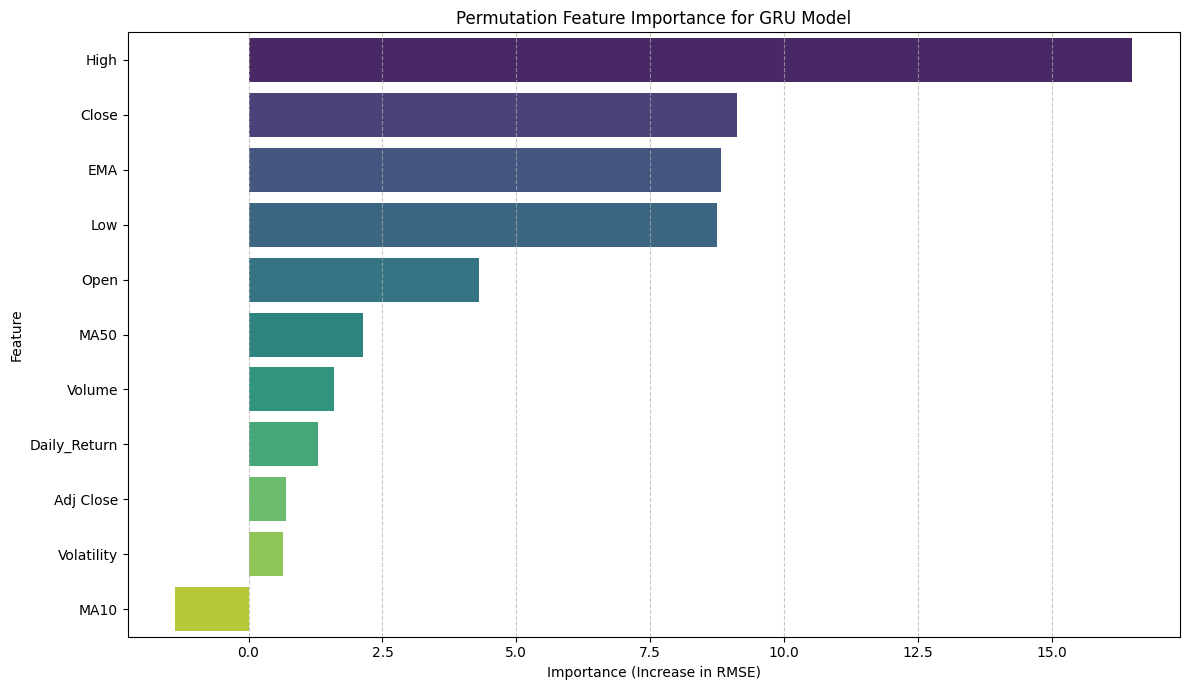

In [22]:
# Calculate baseline RMSE for the GRU model on the test set
baseline_rmse = metrics['GRU']['RMSE']

feature_importance = {}

print("Calculating Permutation Feature Importance...")

for i, feature_name in enumerate(features):
    # Create a copy of the test set
    X_test_shuffled = X_test.copy()

    # Shuffle the current feature's values across all time steps for all samples
    # X_test_shuffled[:, :, i] shuffles the i-th feature column across all samples and all timesteps
    np.random.shuffle(X_test_shuffled[:, :, i])

    # Make predictions with the shuffled data
    shuffled_pred = gru_model.predict(X_test_shuffled, verbose=0)

    # Inverse scale the shuffled predictions
    shuffled_pred_actual = inverse_scale_predictions(shuffled_pred, original_data_shape, close_price_index)

    # Calculate RMSE with shuffled data
    shuffled_rmse = np.sqrt(mean_squared_error(y_test_actual, shuffled_pred_actual))

    # The importance is the increase in RMSE relative to the baseline
    importance_score = shuffled_rmse - baseline_rmse
    feature_importance[feature_name] = importance_score
    print(f"  Feature '{feature_name}': Importance = {importance_score:.4f}")

# Sort features by importance
sorted_importance = sorted(feature_importance.items(), key=lambda item: item[1], reverse=True)
sorted_features = [item[0] for item in sorted_importance]
sorted_scores = [item[1] for item in sorted_importance]

print("\nPermutation Feature Importance (Sorted by Score):")
for feature, score in sorted_importance:
    print(f"  {feature}: {score:.4f}")

# Plotting Feature Importance
plt.figure(figsize=(12, 7))
sns.barplot(x=sorted_scores, y=sorted_features, palette='viridis')
plt.xlabel('Importance (Increase in RMSE)')
plt.ylabel('Feature')
plt.title('Permutation Feature Importance for GRU Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 16. Prepare Files for Streamlit Application

Before creating the Streamlit application files, we need to save the trained GRU model, the `MinMaxScaler`, and important variables like the list of `features`, `look_back` period, the `original_data_shape` and `close_price_index`. These will be loaded by the Streamlit app.

In [7]:
import os
import joblib

# Create the directory if it doesn't exist
app_dir = 'stock-ai-app'
if not os.path.exists(app_dir):
    os.makedirs(app_dir)

# Helper to check and report missing variables
def check_and_save_var(var_name, save_func, path):
    if var_name not in globals():
        print(f"Error: Variable '{var_name}' is not defined. Please ensure the preceding cells that define and train the model and preprocess the data are executed.")
        return False
    try:
        # Special handling for Keras model save
        if var_name == 'gru_model':
            globals()[var_name].save(path)
        else:
            save_func(globals()[var_name], path)
        print(f"{var_name} saved to {path}")
        return True
    except Exception as e:
        print(f"Error saving {var_name} to {path}: {e}")
        return False

# Save the GRU model
check_and_save_var('gru_model', None, os.path.join(app_dir, 'gru_model.h5'))

# Save the scaler
check_and_save_var('scaler', joblib.dump, os.path.join(app_dir, 'scaler.pkl'))

# Save the features list
check_and_save_var('features', joblib.dump, os.path.join(app_dir, 'features.pkl'))

# Save look_back
check_and_save_var('look_back', joblib.dump, os.path.join(app_dir, 'look_back.pkl'))

# Save original_data_shape
check_and_save_var('original_data_shape', joblib.dump, os.path.join(app_dir, 'original_data_shape.pkl'))

# Save close_price_index
check_and_save_var('close_price_index', joblib.dump, os.path.join(app_dir, 'close_price_index.pkl'))

Error: Variable 'gru_model' is not defined. Please ensure the preceding cells that define and train the model and preprocess the data are executed.
Error: Variable 'scaler' is not defined. Please ensure the preceding cells that define and train the model and preprocess the data are executed.
Error: Variable 'features' is not defined. Please ensure the preceding cells that define and train the model and preprocess the data are executed.
Error: Variable 'look_back' is not defined. Please ensure the preceding cells that define and train the model and preprocess the data are executed.
Error: Variable 'original_data_shape' is not defined. Please ensure the preceding cells that define and train the model and preprocess the data are executed.
Error: Variable 'close_price_index' is not defined. Please ensure the preceding cells that define and train the model and preprocess the data are executed.


False